## Задание

Распознайте рукописную цифру, написанную на листе от руки.
Последовательность шагов следующая:

*   На бумаге рисуем произвольную цифру (желательно нарисовать цифру размером не
более 5 * 5 мм и без наклона. В занятии нейронка обучалась на цифрах американских студентов. Эти цифры были написаны на тетрадных листах в клетку и имели схожий размер).
*   Фотографируем. Загружаем фото в Collaboratory.
*   С помощью функции image.load_img(path, target_size=(28, 28), color_mode = ‘grayscale’) загружаем картинку в переменную.
*   С помощью функции image.img_to_array(img) преобразуем изображение в numpy-массив.
*   Выполняем инверсию цветов, нормирование и решейп массива.
*   Выполняем распознавание собственной рукописной цифры.

Примечание: точность распознавания рукописных цифр может быть достаточно низкой, т.к. рукописные цифры после преобразований хоть и похожи на содержащиеся в базе, но могут отличаться по конфигурации, толщине линий и т.д.


In [1]:
# Подключение необходимых библиотек
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras import datasets, utils
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

## Загрузка и подготовка датасета MNIST

In [2]:
# Загрузка датасета MNIST (рукописные цифры 0-9)
(x_train, y_train), (x_test, y_test) = datasets.mnist.load_data()

# Нормализация: приведение значений пикселей к диапазону [0, 1]
x_train = x_train / 255.0
x_test  = x_test  / 255.0

print('Обучающая выборка:', x_train.shape)
print('Тестовая выборка: ', x_test.shape)

Обучающая выборка: (60000, 28, 28)
Тестовая выборка:  (10000, 28, 28)


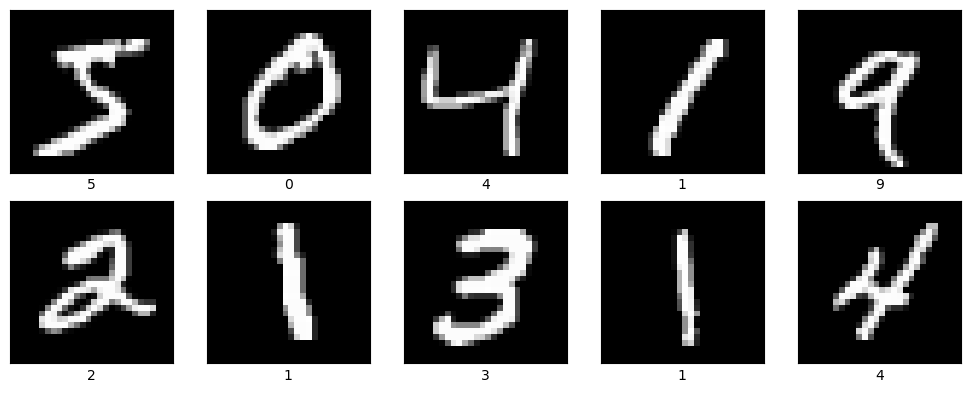

In [3]:
# Просмотр нескольких примеров из датасета
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i], cmap='gray')
    plt.xlabel(y_train[i])
plt.tight_layout()
plt.show()

## Создание и обучение модели

In [4]:
# Создание полносвязной нейронной сети (Dense)
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))   # Выпрямление изображения 28x28 в вектор
model.add(Dense(128, activation='relu'))   # Скрытый слой
model.add(Dense(64,  activation='relu'))   # Скрытый слой
model.add(Dense(10,  activation='softmax'))# Выходной слой: 10 цифр (0-9)

model.compile(
    optimizer=Adam(),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

F:\anaconda3\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         100,480 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [5]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=30,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9089 - loss: 0.3167 - val_accuracy: 0.9567 - val_loss: 0.1579
Epoch 2/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9610 - loss: 0.1304 - val_accuracy: 0.9612 - val_loss: 0.1263
Epoch 3/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9732 - loss: 0.0884 - val_accuracy: 0.9693 - val_loss: 0.1037
Epoch 4/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9794 - loss: 0.0676 - val_accuracy: 0.9707 - val_loss: 0.0984
Epoch 5/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9833 - loss: 0.0531 - val_accuracy: 0.9730 - val_loss: 0.0896
Epoch 6/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9881 - loss: 0.0386 - val_accuracy: 0.9764 - val_loss: 0.0865
Epoch 7/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9900 - loss: 0.0320 - val_accuracy: 0.9740 - val_loss: 0.0889
Epoch 8/30
750/750 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9916 - loss: 0.0266 - val_accuracy: 0.

In [6]:
# Оценка качества модели на тестовой выборке
test_loss, test_accuracy = model.evaluate(x_test, y_test, verbose=0)
print(f'Точность на тестовой выборке: {test_accuracy:.4f}')

Точность на тестовой выборке: 0.9757


## Распознавание рукописной цифры со своего фото

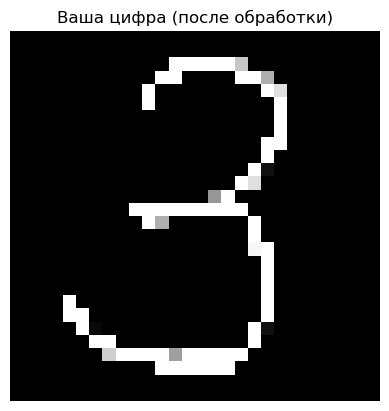

In [12]:
# Загрузка своего фото с цифрой
# Сначала загрузите фото в Colab через значок папки слева → Upload
# Затем укажите имя файла ниже

img_path = 'number.png'  # <-- замените на имя вашего файла

# Загрузка изображения и изменение размера до 28x28 в градациях серого
img = image.load_img(img_path, target_size=(28, 28), color_mode='grayscale')

# Преобразование в numpy-массив
img_array = image.img_to_array(img)

# Инверсия цветов: в MNIST цифра белая на чёрном фоне,
# а на фото обычно наоборот — чёрная на белом
img_array = 255.0 - img_array

# Нормализация
img_array = img_array / 255.0

# Решейп: модель ожидает форму (1, 28, 28)
img_array = img_array.reshape(1, 28, 28)

# Показываем загруженное изображение
plt.imshow(img_array[0], cmap='gray')
plt.title('Ваша цифра (после обработки)')
plt.axis('off')
plt.show()

In [14]:
# Распознавание цифры
prediction = model.predict(img_array)
predicted_digit = np.argmax(prediction[0])
confidence = prediction[0][predicted_digit] * 100

print(f'Распознанная цифра: {predicted_digit}')
print(f'Уверенность модели: {confidence:.1f}%')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Распознанная цифра: 3
Уверенность модели: 80.6%
